Opdracht E3.3 Model Complexity and Optimalisation 

Importeren van de dataset en laden van de data 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

from scipy.stats import ttest_ind, randint

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

# Load data
with zipfile.ZipFile("ecg_data.zip", "r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

print(f'The number of samples: {len(raw_data.index)}')
print(f'The number of columns: {len(raw_data.columns)}')
print(f'The number of NaN values in the dataframe: {raw_data.isnull().sum().sum()}')
print(f'The number of samples with label 0: {len(raw_data[raw_data["label"] == 0])}')
print(f'The number of samples with label 1: {len(raw_data[raw_data["label"] == 1])}')

X = raw_data.drop("label", axis=1)
Y = raw_data["label"]

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=4, stratify=Y
)

The number of samples: 827
The number of columns: 9001
The number of NaN values in the dataframe: 0
The number of samples with label 0: 681
The number of samples with label 1: 146


Preprocessing classes maken 

In [2]:
class VarianceFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.columns_to_drop_ = [col for col in X.columns if np.var(X[col]) < self.threshold]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.columns_to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class TTestFilter(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=0.05):
        self.alpha = alpha

    def fit(self, X, y):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]

        self.columns_to_drop_ = []
        threshold = self.alpha / X.shape[1]  # Bonferroni correction

        for col in X.columns:
            group0 = X.loc[y == 0, col]
            group1 = X.loc[y == 1, col]
            _, p_value = ttest_ind(group0, group1, nan_policy="omit")

            if p_value > threshold:
                self.columns_to_drop_.append(col)

        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")

Preprocessing Pipeline only maken 

In [3]:
preprocess_pipeline = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler())
])

x_train_processed = preprocess_pipeline.fit_transform(x_train, y_train)
x_test_processed = preprocess_pipeline.transform(x_test)

# Zet terug naar DataFrame voor overzicht
selected_features = preprocess_pipeline.named_steps["ttest"].transform(
    preprocess_pipeline.named_steps["correlation"].transform(
        preprocess_pipeline.named_steps["variance"].transform(x_train)
    )
).columns

x_train_processed = pd.DataFrame(x_train_processed, columns=selected_features, index=x_train.index)
x_test_processed = pd.DataFrame(x_test_processed, columns=selected_features, index=x_test.index)

print(f"Start aantal features: {x_train.shape[1]}")
print(f"Na variance filter: {preprocess_pipeline.named_steps['variance'].transform(x_train).shape[1]}")
print(f"Na correlation filter: {preprocess_pipeline.named_steps['correlation'].transform(preprocess_pipeline.named_steps['variance'].transform(x_train)).shape[1]}")
print(f"Na t-test filter: {len(selected_features)}")

Start aantal features: 9000
Na variance filter: 9000
Na correlation filter: 4068
Na t-test filter: 47


Model Complexity and Optimalisation

Model complexity = kijken hoe het zal zijn als de random forest complexer wordt gemaakt 

   n_estimators    PR-AUC   ROC-AUC  Precision    Recall  F1-score
0             1  0.253220  0.595142   0.500000  0.241379  0.325581
1             5  0.383770  0.717594   0.352941  0.206897  0.260870
2            50  0.469688  0.753838   0.857143  0.206897  0.333333
3           200  0.457323  0.755726   0.750000  0.206897  0.324324


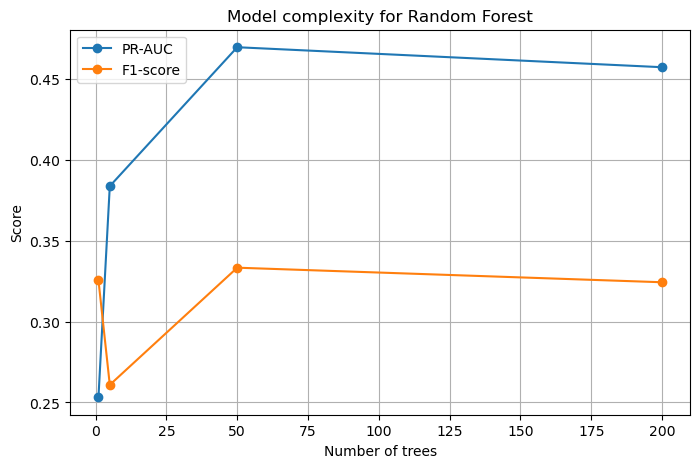

In [4]:
tree_options = [1, 5, 50, 200]
results = []

for n_trees in tree_options:
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(x_train_processed, y_train)
    y_prob = rf.predict_proba(x_test_processed)[:, 1]
    y_pred = rf.predict(x_test_processed)

    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "n_estimators": n_trees,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)
print(results_df)

#plotten van PR-AUC en F1-score tegen aantal bomen in Random Forest

plt.figure(figsize=(8, 5))
plt.plot(results_df["n_estimators"], results_df["PR-AUC"], marker="o", label="PR-AUC")
plt.plot(results_df["n_estimators"], results_df["F1-score"], marker="o", label="F1-score")
plt.xlabel("Number of trees")
plt.ylabel("Score")
plt.title("Model complexity for Random Forest")
plt.legend()
plt.grid(True)
plt.show()

Maken van een learning curve 

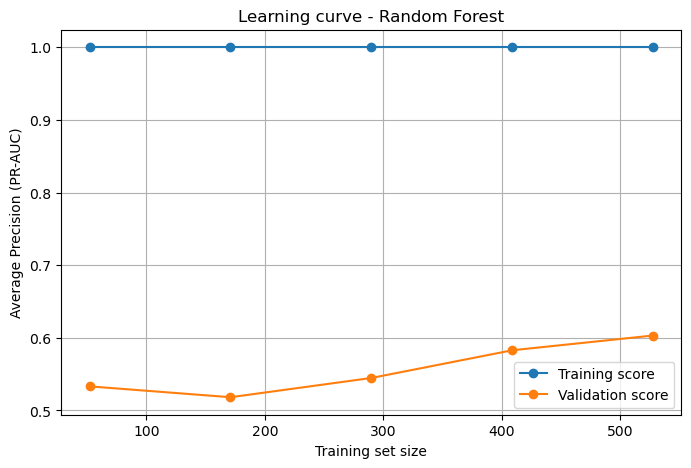

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_learning = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    class_weight="balanced"
)

train_sizes, train_scores, val_scores = learning_curve(
    rf_learning,
    x_train_processed,
    y_train,
    cv=cv,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("Average Precision (PR-AUC)")
plt.title("Learning curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

Hyperparameters testen en optimaliseren  

In [6]:
param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    verbose=0,
    n_jobs=1,
    random_state=42
)

random_search.fit(x_train_processed, y_train)

print("Best parameters:")
print(random_search.best_params_)
print(f"Best cross-validated PR-AUC: {random_search.best_score_:.4f}")

Best parameters:
{'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 356}
Best cross-validated PR-AUC: 0.6374


Beste model evalueren 

Test PR-AUC: 0.5073
Test ROC-AUC: 0.7845
Precision: 0.5833
Recall: 0.2414
F1-score: 0.3415

Classification report:

              precision    recall  f1-score   support

           0       0.86      0.96      0.91       137
           1       0.58      0.24      0.34        29

    accuracy                           0.84       166
   macro avg       0.72      0.60      0.62       166
weighted avg       0.81      0.84      0.81       166

Confusion Matrix:
 [[132   5]
 [ 22   7]]


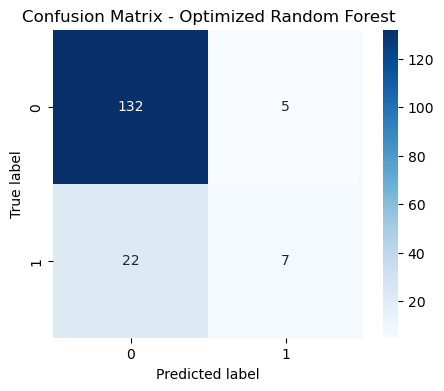

In [7]:
best_rf = random_search.best_estimator_

y_prob = best_rf.predict_proba(x_test_processed)[:, 1]
y_pred = best_rf.predict(x_test_processed)

print(f"Test PR-AUC: {average_precision_score(y_test, y_prob):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0):.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Optimized Random Forest")
plt.show()